# Notebook 05 — Aggregation και Topic Analytics

Σε αυτό το notebook υλοποιείται το επίπεδο aggregation / topic analytics του pipeline. Παίρνουμε τα tweets που επέστρεψε το retrieval layer και τα οργανώνουμε σε θεματικές ομάδες, ώστε η έξοδος να είναι πιο εύκολη στην ανάλυση και παρουσίαση.

Για ένα demo query, τα βήματα είναι:

1. **Retrieve** τα top-K tweets με hybrid search.
2. **Cluster** τα tweets σε micro-topics με K-Means πάνω σε sentence embeddings.
3. **Visualise** τα clusters με UMAP dimensionality reduction.
4. **Extract top terms** ανά cluster με TF-IDF.
5. **Aspect-oriented aggregation** με data-driven aspects που προκύπτουν από τα clusters.
6. **Summarization** με extractive και abstractive μεθόδους.


## 1. Εισαγωγές Βιβλιοθηκών και Αρχική Ρύθμιση

Φορτώνουμε βιβλιοθήκες για clustering, dimensionality reduction, retrieval και visualization. Ορίζουμε επίσης τα paths για τα processed δεδομένα, τα indices και τα aggregation artefacts.


In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer

# Dimensionality reduction
import umap

# Retrieval (reuse from notebook 03)
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
import faiss
import re

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR  = Path('..').resolve()
PROC_DIR  = BASE_DIR / 'data' / 'processed'
INDEX_DIR = BASE_DIR / 'data' / 'index'
AGG_DIR   = BASE_DIR / 'data' / 'aggregation'
AGG_DIR.mkdir(parents=True, exist_ok=True)

EMBED_MODEL = 'all-MiniLM-L6-v2'
TOP_K = 500           # retrieve more tweets for meaningful clustering

EMOTIONS = ['anger', 'anticipation', 'disgust', 'fear', 'joy',
            'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

print('Imports done')

Imports done


**Αποτέλεσμα:** Φορτώθηκαν οι βιβλιοθήκες clustering (`KMeans`, `silhouette_score`), dimensionality reduction (`umap`) και retrieval. Δημιουργήθηκε ο φάκελος `data/aggregation/` για τα αποτελέσματα. Το `TOP_K = 500` χρησιμοποιείται ώστε το demo clustering να έχει αρκετά tweets για πιο σταθερή θεματική εικόνα.


## 2. Φόρτωση Corpus, Indices και Search Functions

Φορτώνουμε τα artefacts που έχουν ήδη παραχθεί από τα προηγούμενα notebooks: το processed corpus, τον BM25 index, τα sentence embeddings, τον FAISS index και το embedding model.


In [2]:
# ── Load corpus ────────────────────────────────────────────────────────────────
df = pd.read_parquet(PROC_DIR / 'tweets_processed.parquet')
df = df.reset_index(drop=True)
print(f'Corpus : {len(df):,} tweets')

# ── Load BM25 ──────────────────────────────────────────────────────────────────
with open(INDEX_DIR / 'bm25.pkl', 'rb') as f:
    bm25 = pickle.load(f)
print('BM25 index loaded')

# ── Load embeddings & FAISS ────────────────────────────────────────────────────
embeddings = np.load(INDEX_DIR / 'embeddings.npy')
faiss_index = faiss.read_index(str(INDEX_DIR / 'faiss.index'))
print(f'FAISS index loaded : {faiss_index.ntotal:,} vectors, dim={embeddings.shape[1]}')

# ── Load sentence-transformer ──────────────────────────────────────────────────
embedder = SentenceTransformer(EMBED_MODEL)
print(f'Embedder loaded : {EMBED_MODEL}')

Corpus : 10,896 tweets
BM25 index loaded
FAISS index loaded : 10,896 vectors, dim=384
Embedder loaded : all-MiniLM-L6-v2


**Αποτέλεσμα:** Φορτώθηκαν επιτυχώς το corpus με 10.896 tweets, ο BM25 index, τα embeddings με shape `10.896 × 384`, ο FAISS index και ο embedder. Αυτό το notebook δεν ξαναχτίζει indices· τα χρησιμοποιεί για aggregation πάνω στα retrieved tweets.


### 2.1 Search Functions για Hybrid Retrieval

Ορίζονται ξανά οι βασικές search functions από το Notebook 03, ώστε το notebook να είναι self-contained. Η λογική παραμένει ίδια: BM25 score, semantic score και τελικό hybrid score με weighted fusion.


In [3]:
# ── Search functions (copied from notebook 03 for self-containment) ────────────

def preprocess_query(query: str) -> list[str]:
    query = query.lower()
    query = re.sub(r'https?://\\S+|www\\.\\S+', '', query)
    query = re.sub(r'[^a-z0-9\\s]', ' ', query)
    return query.split()


def minmax_norm(arr: np.ndarray) -> np.ndarray:
    lo, hi = arr.min(), arr.max()
    if hi == lo:
        return np.zeros_like(arr)
    return (arr - lo) / (hi - lo)


def hybrid_search(query: str,
                  bm25_index: BM25Okapi,
                  embedder_model: SentenceTransformer,
                  faiss_idx,
                  corpus_df: pd.DataFrame,
                  top_k: int = TOP_K,
                  alpha: float = 0.3) -> pd.DataFrame:
    tokens     = preprocess_query(query)
    bm25_raw   = bm25_index.get_scores(tokens)
    bm25_norm  = minmax_norm(bm25_raw)

    q_emb = embedder_model.encode([query], normalize_embeddings=True, convert_to_numpy=True)
    sem_raw, sem_idx = faiss_idx.search(q_emb, faiss_idx.ntotal)
    sem_raw  = sem_raw[0]
    sem_idx  = sem_idx[0]

    sem_aligned = np.empty(len(corpus_df), dtype=np.float32)
    sem_aligned[sem_idx] = sem_raw
    sem_norm = minmax_norm(sem_aligned)

    hybrid = alpha * bm25_norm + (1 - alpha) * sem_norm
    top_idx = np.argsort(hybrid)[::-1][:top_k]

    result = corpus_df.iloc[top_idx].copy()
    result['hybrid_score'] = hybrid[top_idx]
    result.insert(0, 'rank', range(1, top_k + 1))
    return result

print('Search functions ready')

Search functions ready


**Αποτέλεσμα:** Ορίστηκαν οι search functions για hybrid retrieval. Το notebook μπορεί πλέον να ανακτήσει tweets χωρίς να εισάγει κώδικα από άλλο notebook.


## 3. Ανάκτηση Tweets για Demo Query

Χρησιμοποιούμε το query `education technology electronics ai` και ανακτούμε τα top-500 tweets με hybrid search. Στη συνέχεια κρατάμε και τα αντίστοιχα pre-computed embeddings, επειδή αυτά θα χρησιμοποιηθούν για clustering και UMAP.


In [4]:
QUERY = 'education technology electronics ai'

retrieved = hybrid_search(QUERY, bm25, embedder, faiss_index, df, top_k=TOP_K)
print(f'Query      : "{QUERY}"')
print(f'Retrieved  : {len(retrieved)} tweets')
print(f'Score range: {retrieved["hybrid_score"].min():.4f} – {retrieved["hybrid_score"].max():.4f}')

# Get embeddings for retrieved tweets
retrieved_indices = retrieved.index.tolist()
retrieved_embeddings = embeddings[retrieved_indices]
print(f'Embeddings : {retrieved_embeddings.shape}')

Query      : "education technology electronics ai"
Retrieved  : 500 tweets
Score range: 0.3843 – 0.9427
Embeddings : (500, 384)


**Αποτέλεσμα:** Για το query `education technology electronics ai`, ανακτήθηκαν 500 tweets με hybrid scores στο εύρος `[0.3843, 0.9427]`. Εξήχθησαν και τα αντίστοιχα embeddings με shape `500 × 384`, χωρίς νέο encoding.


---

## 4. Clustering — Εντοπισμός Micro-Topics

Ομαδοποιούμε τα retrieved tweets με K-Means πάνω στα sentence embeddings τους. Έτσι δημιουργούνται micro-topics που βασίζονται στη σημασιολογική εγγύτητα των tweets και όχι μόνο σε κοινές λέξεις.

### 4.1 Επιλογή Optimal K (Elbow + Silhouette)

Δοκιμάζουμε διαφορετικές τιμές για `K` και αξιολογούμε με inertia (Elbow Method) και silhouette score. Το silhouette score δείχνει πόσο καλά διαχωρίζονται τα clusters μεταξύ τους.


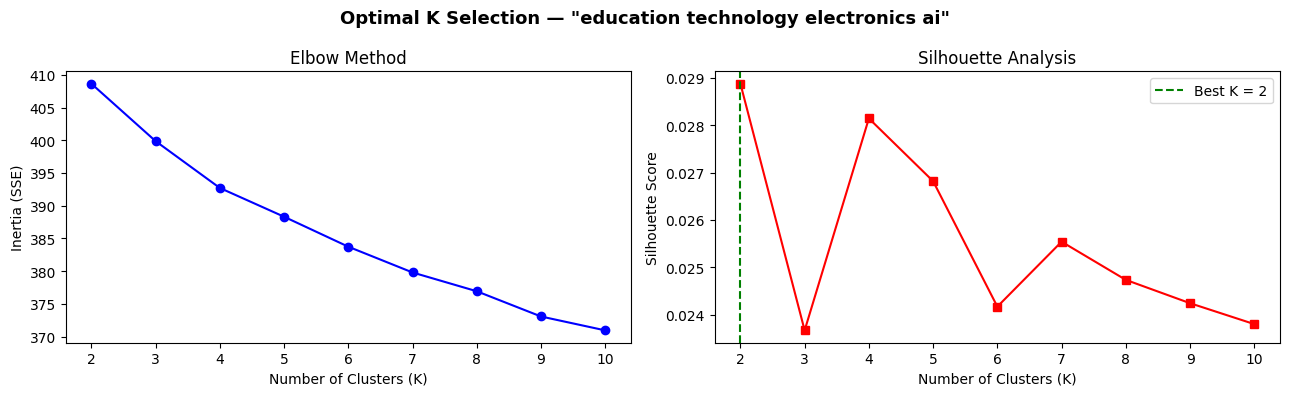


Best K by silhouette: 2 (score = 0.0289)


In [5]:
K_RANGE = range(2, 11)

inertias  = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(retrieved_embeddings)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(retrieved_embeddings, labels))

# ── Plot ────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(K_RANGE, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (SSE)')
ax1.set_title('Elbow Method')

ax2.plot(K_RANGE, sil_scores, 'rs-')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')

best_k = list(K_RANGE)[np.argmax(sil_scores)]
ax2.axvline(best_k, color='green', linestyle='--', label=f'Best K = {best_k}')
ax2.legend()

fig.suptitle(f'Optimal K Selection — "{QUERY}"', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(AGG_DIR / 'elbow_silhouette.png', dpi=120)
plt.show()

print(f'\nBest K by silhouette: {best_k} (score = {max(sil_scores):.4f})')

**Αποτέλεσμα:** Δοκιμάστηκαν τιμές `k=2` έως `k=10`. Το silhouette score επέλεξε **best K = 2**, άρα τα 500 tweets χωρίζονται φυσικά σε δύο ομάδες. Το plot αποθηκεύτηκε στο `data/aggregation/elbow_silhouette.png`.

![Elbow Method και Silhouette Analysis για Optimal K Selection](../data/aggregation/elbow_silhouette.png)


### 4.2 Εφαρμογή K-Means με το Best K

Με βάση το best K που προέκυψε από το silhouette score, εφαρμόζουμε K-Means και αναθέτουμε κάθε retrieved tweet σε ένα cluster.


In [6]:
CHOSEN_K = best_k    # or override manually

kmeans = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
retrieved['cluster'] = kmeans.fit_predict(retrieved_embeddings)

print(f'Clusters assigned (K={CHOSEN_K}):')
print(retrieved['cluster'].value_counts().sort_index())

Clusters assigned (K=2):
cluster
0    286
1    214
Name: count, dtype: int64


**Αποτέλεσμα:** Το K-Means με `K=2` ανέθεσε κάθε tweet σε ένα cluster: **Cluster 0: 286 tweets** και **Cluster 1: 214 tweets**. Τα clusters είναι σχετικά ισορροπημένα. Το `n_init=10` τρέχει τον αλγόριθμο με διαφορετικές αρχικοποιήσεις και κρατάει την καλύτερη λύση.


### 4.3 Top Terms ανά Cluster (TF-IDF)

Για να δώσουμε ανθρώπινα κατανοητή περιγραφή σε κάθε cluster, εφαρμόζουμε TF-IDF στα `text_clean` tweets κάθε ομάδας και κρατάμε τους όρους με τον μεγαλύτερο μέσο TF-IDF score.


In [7]:
def get_top_terms_per_cluster(df_in, cluster_col='cluster', text_col='text_clean',
                               n_terms=10):
    """
    For each cluster, fit TF-IDF and return top terms.
    """
    results = {}
    for cid in sorted(df_in[cluster_col].unique()):
        texts = df_in[df_in[cluster_col] == cid][text_col].tolist()
        tfidf = TfidfVectorizer(max_features=200, stop_words='english')
        X = tfidf.fit_transform(texts)
        # Average TF-IDF per term
        mean_scores = X.mean(axis=0).A1
        feature_names = tfidf.get_feature_names_out()
        top_idx = mean_scores.argsort()[::-1][:n_terms]
        results[cid] = [(feature_names[i], round(mean_scores[i], 4)) for i in top_idx]
    return results


top_terms = get_top_terms_per_cluster(retrieved)

print(f'Top-10 TF-IDF Terms per Cluster (K={CHOSEN_K})\n')
print('═' * 80)
for cid, terms in top_terms.items():
    cluster_size = len(retrieved[retrieved['cluster'] == cid])
    term_str = ' | '.join([f'{t[0]} ({t[1]:.3f})' for t in terms])
    print(f'  Cluster {cid} ({cluster_size:>3} tweets): {term_str}')
print('═' * 80)

Top-10 TF-IDF Terms per Cluster (K=2)

════════════════════════════════════════════════════════════════════════════════
  Cluster 0 (286 tweets): amp (0.046) | new (0.038) | alarm (0.034) | like (0.027) | india (0.021) | need (0.020) | glee (0.019) | love (0.019) | start (0.018) | people (0.018)
  Cluster 1 (214 tweets): school (0.052) | class (0.039) | college (0.029) | learning (0.028) | lost (0.027) | know (0.026) | amp (0.025) | good (0.025) | discouraged (0.024) | time (0.023)
════════════════════════════════════════════════════════════════════════════════


**Αποτέλεσμα:** Τα top TF-IDF terms αποκαλύπτουν τη θεματική ταυτότητα κάθε cluster:

- **Cluster 0** (286 tweets): `amp | new | alarm | india | glee` — γενικό/τεχνολογικό περιεχόμενο
- **Cluster 1** (214 tweets): `school | class | college | learning | lost | discouraged` — εκπαιδευτικό περιεχόμενο

Αυτοί οι όροι θα χρησιμοποιηθούν ως **aspect labels**, δηλαδή σύντομες και κατανοητές περιγραφές των clusters.


### 4.4 UMAP Visualization των Clusters

Μειώνουμε τα 384-dimensional embeddings σε δύο διαστάσεις με UMAP, ώστε να οπτικοποιήσουμε τα clusters σε scatter plot. Κάθε σημείο αντιστοιχεί σε ένα tweet.


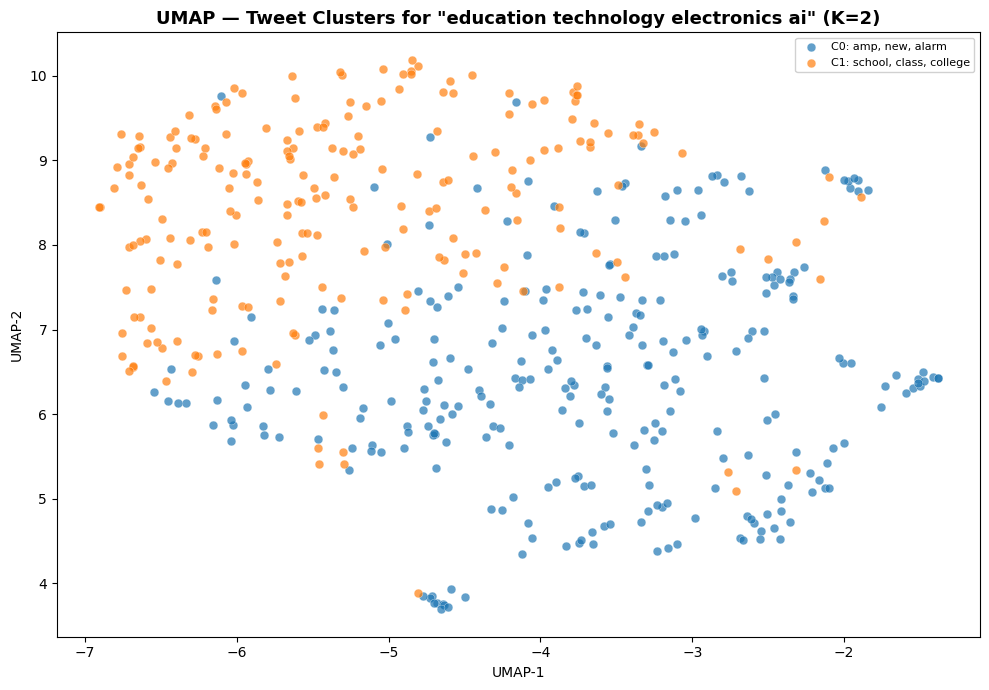

UMAP cluster visualisation saved.


In [8]:
# ── UMAP reduction to 2D ───────────────────────────────────────────────────────
reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine')
umap_2d = reducer.fit_transform(retrieved_embeddings)

retrieved['umap_x'] = umap_2d[:, 0]
retrieved['umap_y'] = umap_2d[:, 1]

# ── Plot ────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

palette = sns.color_palette('tab10', n_colors=CHOSEN_K)

for cid in range(CHOSEN_K):
    mask = retrieved['cluster'] == cid
    # Top-3 terms as label
    label_terms = ', '.join([t[0] for t in top_terms[cid][:3]])
    ax.scatter(
        retrieved.loc[mask, 'umap_x'],
        retrieved.loc[mask, 'umap_y'],
        c=[palette[cid]],
        label=f'C{cid}: {label_terms}',
        alpha=0.7,
        s=40,
        edgecolors='white',
        linewidth=0.3,
    )

ax.set_title(f'UMAP — Tweet Clusters for "{QUERY}" (K={CHOSEN_K})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.legend(fontsize=8, loc='best', framealpha=0.9)
plt.tight_layout()
fig.savefig(AGG_DIR / 'umap_clusters.png', dpi=120)
plt.show()

print('UMAP cluster visualisation saved.')

**Αποτέλεσμα:** Το UMAP συμπίεσε τα embeddings σε 2D και τα δύο clusters εμφανίζονται ως διακριτά νέφη σημείων. Αυτό επιβεβαιώνει ότι το K-Means βρήκε σημασιολογικά διαχωρίσιμες ομάδες. Το plot αποθηκεύτηκε στο `data/aggregation/umap_clusters.png`.

![UMAP Projection — Tweet Clusters](../data/aggregation/umap_clusters.png)


### 4.5 Emotion Distribution ανά Cluster

Υπολογίζουμε τον μέσο όρο κάθε emotion label μέσα σε κάθε cluster. Αυτό δείχνει ποια συναισθήματα κυριαρχούν σε κάθε micro-topic.


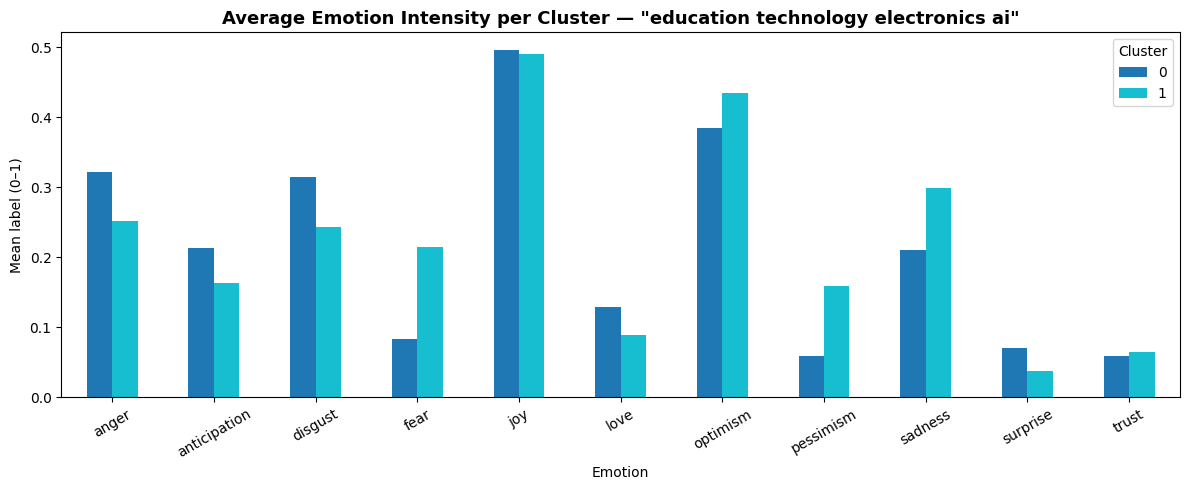

Emotion per cluster chart saved.


In [9]:
# ── Per-cluster emotion distribution ───────────────────────────────────────────
emo_by_cluster = retrieved.groupby('cluster')[EMOTIONS].mean()

fig, ax = plt.subplots(figsize=(12, 5))
emo_by_cluster.T.plot(kind='bar', ax=ax, colormap='tab10')
ax.set_title(f'Average Emotion Intensity per Cluster — "{QUERY}"',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Emotion')
ax.set_ylabel('Mean label (0–1)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Cluster', loc='upper right')
plt.tight_layout()
fig.savefig(AGG_DIR / 'emotion_per_cluster.png', dpi=120)
plt.show()

print('Emotion per cluster chart saved.')

**Αποτέλεσμα:** Το bar chart δείχνει τη μέση ένταση κάθε emotion ανά cluster. Το εκπαιδευτικό cluster έχει υψηλότερο `fear` και `sadness`, ενώ το γενικό/τεχνολογικό cluster εμφανίζει περισσότερο `optimism` και `joy`. Το plot αποθηκεύτηκε στο `data/aggregation/emotion_per_cluster.png`.

![Average Emotion Intensity per Cluster](../data/aggregation/emotion_per_cluster.png)


## 5. Aspect-Oriented Aggregation (Auto-Discovered)

Τα aspects δεν δίνονται χειροκίνητα και δεν βασίζονται σε domain dictionaries. Προκύπτουν αυτόματα από τα clusters και ονομάζονται με βάση τα top TF-IDF terms κάθε cluster. Έτσι η ανάλυση μένει data-driven.


In [10]:
# ── Auto-discover aspects from clusters ────────────────────────────────────────

def auto_discover_aspects(df_in, top_terms_dict, n_label_terms=3):
    """
    Use cluster labels as aspects, named by their top TF-IDF terms.
    No predefined dictionaries needed — fully data-driven.
    """
    df_out = df_in.copy()

    # Map cluster id → readable label from top terms
    aspect_labels = {}
    for cid, terms in top_terms_dict.items():
        label = ', '.join([t[0] for t in terms[:n_label_terms]])
        aspect_labels[cid] = label

    df_out['aspect'] = df_out['cluster'].map(aspect_labels)

    # aspect_score = how close each tweet is to its cluster centroid
    # (reuse the approach from clustering — higher = more representative)
    scores = []
    for _, row in df_out.iterrows():
        cid = row['cluster']
        pos = df_in.index.get_loc(row.name)
        emb = retrieved_embeddings[pos]
        centroid = kmeans.cluster_centers_[cid]
        # cosine similarity
        sim = np.dot(emb, centroid) / (np.linalg.norm(emb) * np.linalg.norm(centroid) + 1e-10)
        scores.append(sim)
    df_out['aspect_score'] = scores

    return df_out


retrieved = auto_discover_aspects(retrieved, top_terms)

print(f'Auto-discovered aspects for "{QUERY}":')
print()
for asp in sorted(retrieved['aspect'].unique()):
    n = len(retrieved[retrieved['aspect'] == asp])
    print(f'  • {asp}  ({n} tweets)')


Auto-discovered aspects for "education technology electronics ai":

  • amp, new, alarm  (286 tweets)
  • school, class, college  (214 tweets)


**Αποτέλεσμα:** Τα aspects ανακαλύφθηκαν αυτόματα από τα clusters:

- Aspect `amp, new, alarm` → 286 tweets (γενικό/τεχνολογικό)
- Aspect `school, class, college` → 214 tweets (εκπαιδευτικό)

Για κάθε tweet υπολογίστηκε `aspect_score`, δηλαδή cosine similarity με το centroid του cluster. Όσο μεγαλύτερο είναι το score, τόσο πιο αντιπροσωπευτικό είναι το tweet για το aspect του.


### 5.1 Emotion Distribution ανά Aspect

Για κάθε auto-discovered aspect υπολογίζουμε τη μέση ενεργοποίηση των 11 emotions. Παρουσιάζουμε τα ίδια δεδομένα με δύο τρόπους: heatmap για συνολική εικόνα και grouped bar chart για πιο άμεση σύγκριση μεταξύ aspects.


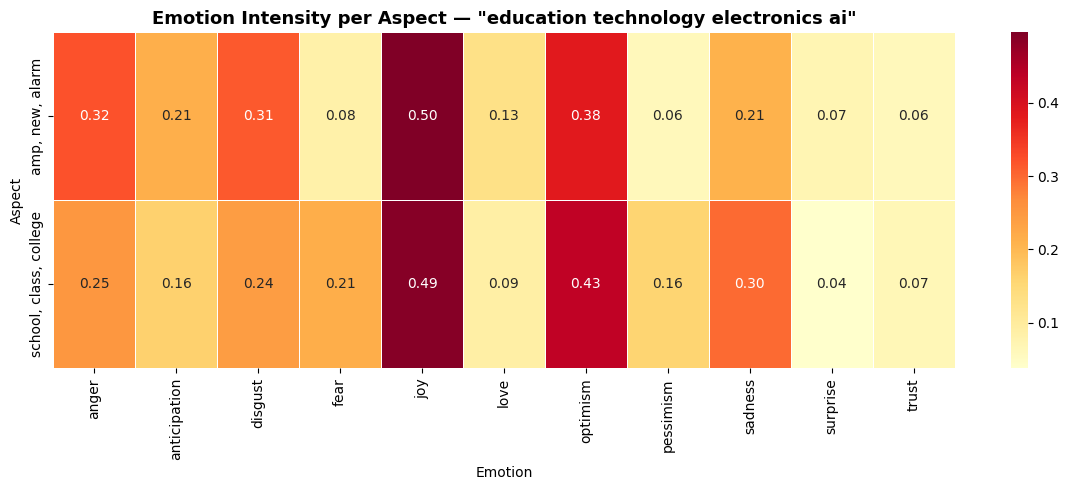

Per-aspect emotion heatmap saved.


In [11]:
# ── Per-aspect emotion heatmap ─────────────────────────────────────────────────
emo_by_aspect = retrieved.groupby('aspect')[EMOTIONS].mean()

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    emo_by_aspect,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
)
ax.set_title(f'Emotion Intensity per Aspect — "{QUERY}"',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Aspect')
ax.set_xlabel('Emotion')
plt.tight_layout()
fig.savefig(AGG_DIR / 'emotion_per_aspect_heatmap.png', dpi=120)
plt.show()

print('Per-aspect emotion heatmap saved.')

**Αποτέλεσμα:** Το heatmap δείχνει την ένταση κάθε emotion ανά aspect. Rows = aspects, columns = emotions. Αποθηκεύτηκε στο `data/aggregation/emotion_per_aspect_heatmap.png`.

![Emotion Intensity per Aspect — Heatmap](../data/aggregation/emotion_per_aspect_heatmap.png)


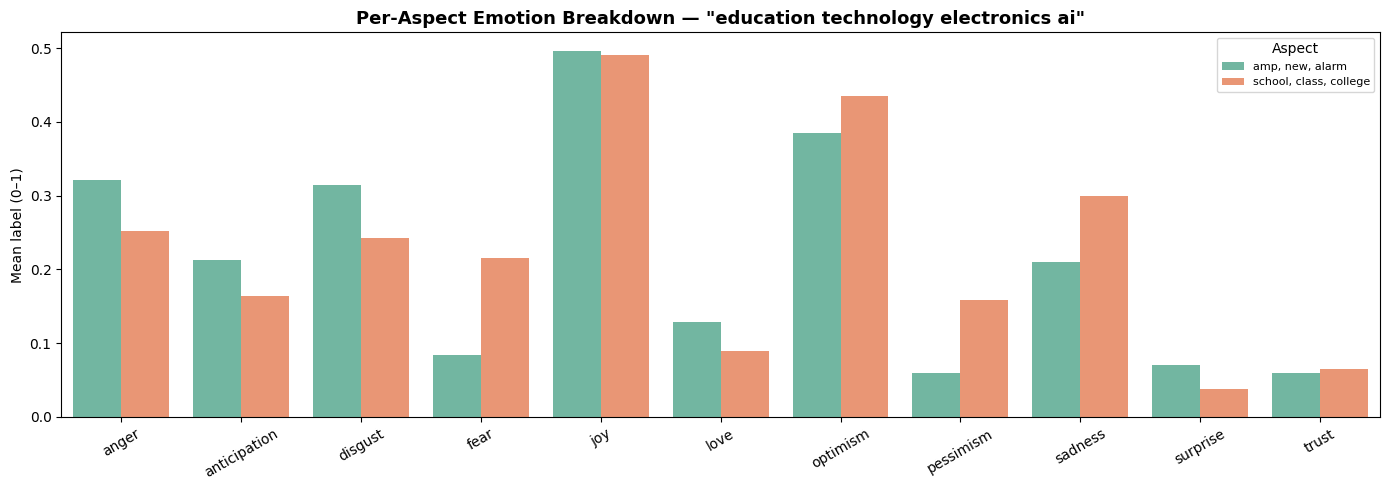

Per-aspect bar chart saved.


In [12]:
# ── Grouped bar chart: Aspect × Emotion ────────────────────────────────────────
emo_melted = emo_by_aspect.reset_index().melt(
    id_vars='aspect', var_name='Emotion', value_name='Mean Label'
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(
    data=emo_melted, x='Emotion', y='Mean Label', hue='aspect',
    palette='Set2', ax=ax,
)
ax.set_title(f'Per-Aspect Emotion Breakdown — "{QUERY}"',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Mean label (0–1)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Aspect', loc='upper right', fontsize=8)
plt.tight_layout()
fig.savefig(AGG_DIR / 'emotion_per_aspect_bars.png', dpi=120)
plt.show()

print('Per-aspect bar chart saved.')

**Αποτέλεσμα:** Το grouped bar chart δείχνει τα ίδια per-aspect emotion statistics σε μορφή που διευκολύνει τη σύγκριση ανά emotion. Αποθηκεύτηκε στο `data/aggregation/emotion_per_aspect_bars.png`.

![Per-Aspect Emotion Breakdown — Bar Chart](../data/aggregation/emotion_per_aspect_bars.png)


### 5.2 Representative Tweets ανά Aspect

Για κάθε aspect εμφανίζουμε τα top-3 πιο αντιπροσωπευτικά tweets με βάση το `aspect_score`. Αυτά βοηθούν να καταλάβουμε γρήγορα τι εκφράζει κάθε θεματική ομάδα.


In [13]:
# ── Show top-3 tweets per aspect (by aspect_score) ─────────────────────────────
print(f'Top-3 Representative Tweets per Aspect — "{QUERY}"')
print('═' * 90)

for aspect in sorted(retrieved['aspect'].unique()):
    subset = retrieved[retrieved['aspect'] == aspect].nlargest(3, 'aspect_score')
    emo_str = ', '.join(
        [e for e in EMOTIONS if subset[e].sum() > 0]
    )
    print(f'\n▸ {aspect.upper()} ({len(retrieved[retrieved["aspect"] == aspect])} tweets)')
    print(f'  Dominant emotions: {emo_str or "—"}')
    for _, row in subset.iterrows():
        emotions_on = ', '.join([e for e in EMOTIONS if row[e] == 1]) or '—'
        print(f'    [{row["aspect_score"]:.3f}] [{emotions_on}]')
        print(f'           {row["Tweet"][:120]}')

print('\n' + '═' * 90)

Top-3 Representative Tweets per Aspect — "education technology electronics ai"
══════════════════════════════════════════════════════════════════════════════════════════

▸ AMP, NEW, ALARM (286 tweets)
  Dominant emotions: fear, joy, love, optimism
    [0.621] [joy, optimism]
           @edutopia What an innovative way for admin to see what's going on in classrooms! #leadup #awesomeness
    [0.618] [love, optimism]
           @KendallJenner #Love lights #up old tasks will soon going and!!! #serious
    [0.618] [fear]
           Good Morning!!!\n\n#leadership #healthcareIT #socialmedia #connector #ceo #writer #AI #EQ #security #bigdata #Growthhack

▸ SCHOOL, CLASS, COLLEGE (214 tweets)
  Dominant emotions: anticipation, fear, joy, love, optimism, surprise
    [0.641] [anticipation, fear, joy, love]
           Three more shifts then I start the next part of my tutorship in response #enjoyingthelastfewdays #excited #nervous #newc
    [0.640] [joy, surprise]
           So happy my next cla

**Αποτέλεσμα:** Τα top-3 tweets ανά aspect δείχνουν παραδείγματα που βρίσκονται κοντά στο centroid της ομάδας τους. Για το εκπαιδευτικό aspect εμφανίζονται tweets σχετικά με σχολείο, μάθηση και διδασκαλία, οπότε η αντιστοίχιση aspect → περιεχόμενο είναι ερμηνεύσιμη.


### 5.3 Extractive Summary

Η extractive summary δεν γράφει νέο κείμενο. Επιλέγει τα 3 tweets που είναι πιο κοντά στο centroid κάθε aspect στο embedding space.

**Μέθοδος:**

1. Υπολογίζουμε το centroid των embeddings κάθε aspect.
2. Υπολογίζουμε cosine similarity κάθε tweet με το centroid.
3. Επιλέγουμε τα tweets με τη μεγαλύτερη similarity.

Έτσι παίρνουμε αντιπροσωπευτικά tweets, όχι απαραίτητα τα tweets με το υψηλότερο retrieval score.


In [14]:
# ── Extractive Summary: centroid-nearest tweets per aspect ─────────────────────

def extractive_summary(df_in, embeddings_in, group_col='aspect', n_top=3):
    """
    Centroid-nearest extractive summariser.
    For each group, compute the centroid of its embeddings and return
    the n_top tweets closest to that centroid (= most representative).
    """
    summaries = {}
    for group_name in sorted(df_in[group_col].unique()):
        mask = df_in[group_col] == group_name
        group_indices = df_in.index[mask].tolist()
        group_positions = [df_in.index.get_loc(idx) for idx in group_indices]
        group_embs = embeddings_in[group_positions]

        # Centroid
        centroid = group_embs.mean(axis=0, keepdims=True)
        centroid = centroid / np.linalg.norm(centroid)     # normalise

        # Cosine similarity to centroid
        norms = np.linalg.norm(group_embs, axis=1, keepdims=True)
        norms[norms == 0] = 1
        sims = (group_embs / norms) @ centroid.T
        sims = sims.flatten()

        # Top-n nearest to centroid
        top_local_idx = sims.argsort()[::-1][:n_top]
        top_global_idx = [group_indices[i] for i in top_local_idx]
        top_sims = sims[top_local_idx]

        summaries[group_name] = {
            'tweets': df_in.loc[top_global_idx, 'Tweet'].tolist(),
            'scores': top_sims.tolist(),
            'emotions': [
                ', '.join([e for e in EMOTIONS if df_in.loc[idx, e] == 1]) or '—'
                for idx in top_global_idx
            ],
        }
    return summaries


extractive = extractive_summary(retrieved, retrieved_embeddings, group_col='aspect', n_top=3)

print(f'EXTRACTIVE SUMMARY (centroid-nearest) — "{QUERY}"')
print('═' * 90)
for aspect, data in extractive.items():
    n_total = len(retrieved[retrieved['aspect'] == aspect])
    print(f'\n▸ {aspect.upper()} ({n_total} tweets)')
    for i, (tweet, sim, emo) in enumerate(zip(data['tweets'], data['scores'], data['emotions'])):
        print(f'    {i+1}. [sim={sim:.3f}] [{emo}]')
        print(f'       {tweet[:130]}')
print('\n' + '═' * 90)


EXTRACTIVE SUMMARY (centroid-nearest) — "education technology electronics ai"
══════════════════════════════════════════════════════════════════════════════════════════

▸ AMP, NEW, ALARM (286 tweets)
    1. [sim=0.621] [joy, optimism]
       @edutopia What an innovative way for admin to see what's going on in classrooms! #leadup #awesomeness
    2. [sim=0.618] [love, optimism]
       @KendallJenner #Love lights #up old tasks will soon going and!!! #serious
    3. [sim=0.618] [fear]
       Good Morning!!!\n\n#leadership #healthcareIT #socialmedia #connector #ceo #writer #AI #EQ #security #bigdata #Growthhacking #tech 

▸ SCHOOL, CLASS, COLLEGE (214 tweets)
    1. [sim=0.641] [anticipation, fear, joy, love]
       Three more shifts then I start the next part of my tutorship in response #enjoyingthelastfewdays #excited #nervous #newchallanges
    2. [sim=0.640] [joy, surprise]
       So happy my next class is canceled bc..im od tired 😭
    3. [sim=0.636] [joy, love, optimism]
       Tuto

**Αποτέλεσμα — Extractive Summary:** Για κάθε aspect, η συνάρτηση υπολόγισε το centroid και επέλεξε τα 3 tweets με την υψηλότερη cosine similarity προς αυτό. Αυτά είναι τα πιο αντιπροσωπευτικά tweets της ομάδας και λειτουργούν ως αξιόπιστη σύνοψη χωρίς κίνδυνο hallucination.


### 5.4 Abstractive Summary

Χρησιμοποιούμε το `sshleifer/distilbart-cnn-12-6`, ένα pre-trained abstractive summarization model. Το μοντέλο παίρνει ως input τα top-10 tweets κάθε aspect, τα συνενώνει και παράγει νέο summary text.

> Στην πρώτη εκτέλεση το μοντέλο κατεβαίνει από το HuggingFace Hub. Στις επόμενες εκτελέσεις φορτώνεται από local cache.


In [15]:
from transformers import pipeline
import torch

# ── Load abstractive summarisation model ───────────────────────────────────────
SUMMARIZER_MODEL = 'sshleifer/distilbart-cnn-12-6'

device_id = 0 if torch.cuda.is_available() else -1
print(f'Loading summariser: {SUMMARIZER_MODEL}')
print(f'Device: {"cuda" if device_id == 0 else "cpu"}')

summarizer = pipeline(
    'summarization',
    model=SUMMARIZER_MODEL,
    device=device_id,
)
print('Summariser loaded.\n')


# ── Abstractive summary per aspect ─────────────────────────────────────────────
def abstractive_summary(df_in, summarizer_pipe, group_col='aspect',
                        text_col='Tweet', n_input=10,
                        max_length=80, min_length=20):
    """
    For each group, concatenate the top-n tweets and generate
    an abstractive summary with the summarisation pipeline.
    """
    summaries = {}
    for group_name in sorted(df_in[group_col].unique()):
        subset = df_in[df_in[group_col] == group_name]
        # Take top-n by hybrid_score (most relevant)
        top_tweets = subset.nlargest(n_input, 'hybrid_score')[text_col].tolist()
        # Concatenate for input
        concat_text = ' '.join([t.strip() for t in top_tweets])
        # Truncate if too long (model max ~1024 tokens)
        concat_text = concat_text[:2048]

        try:
            result = summarizer_pipe(
                concat_text,
                max_length=max_length,
                min_length=min_length,
                do_sample=False,
            )
            summaries[group_name] = result[0]['summary_text']
        except Exception as e:
            summaries[group_name] = f'[Error: {e}]'

    return summaries


abstractive = abstractive_summary(retrieved, summarizer, group_col='aspect')

print(f'ABSTRACTIVE SUMMARY (DistilBART) — "{QUERY}"')
print('═' * 90)
for aspect, summary_text in abstractive.items():
    n_total = len(retrieved[retrieved['aspect'] == aspect])
    print(f'\n▸ {aspect.upper()} ({n_total} tweets)')
    print(f'    {summary_text}')
print('\n' + '═' * 90)


Loading summariser: sshleifer/distilbart-cnn-12-6
Device: cpu


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Device set to use cpu


Summariser loaded.

ABSTRACTIVE SUMMARY (DistilBART) — "education technology electronics ai"
══════════════════════════════════════════════════════════════════════════════════════════

▸ AMP, NEW, ALARM (286 tweets)
     @emilyhroderick Electronics also have foibles, personality faults, like to sulk and crash just like humans... switch off and desolder #AI #revolation, soon is possible! @FoxNews #Poor = #angry and justly so. Offer people some hope! My god, does anyone see this?! #Education should not be for the #

▸ SCHOOL, CLASS, COLLEGE (214 tweets)
     Just go outside (or to the gym hall) and play! #education  #learning @LaneWoolery @FFKazman experience all plays a role in that, it's education and preparedness not fear . Early childhood demonstrates #pleasure seeking behavior and it can’t be considered as the vital tool of knowledge learning .

══════════════════════════════════════════════════════════════════════════════════════════


**Αποτέλεσμα — Abstractive Summary (DistilBART):** Το μοντέλο παράγει νέο κείμενο που δεν υπάρχει αυτολεξεί στα tweets. Παρατηρείται όμως **domain mismatch**, επειδή το DistilBART έχει εκπαιδευτεί σε CNN/DailyMail news articles και όχι σε tweets. Για αυτό το output είναι πιο αναγνώσιμο, αλλά μπορεί να είναι λιγότερο πιστό ή μερικώς ασύνδετο.


## 6. Σύγκριση Extractive vs Abstractive Summary

| Μέθοδος | Πώς δουλεύει | Πλεονεκτήματα | Περιορισμοί |
|---|---|---|---|
| **Representative** | Επιλέγει tweets με υψηλό hybrid retrieval score | Δείχνει τα πιο σχετικά ως προς το query | Μπορεί να είναι outliers για το aspect |
| **Extractive Summary** | Επιλέγει centroid-nearest tweets | Πιστό στο αρχικό κείμενο, χωρίς hallucination | Δεν παράγει νέο κείμενο |
| **Abstractive Summary** | Το μοντέλο γράφει νέο summary | Πιο αναγνώσιμο και συμπυκνωμένο | Πιο αργό και πιθανό domain mismatch |


In [16]:
# ── Side-by-side comparison table ──────────────────────────────────────────────
rows = []
for aspect in sorted(retrieved['aspect'].unique()):
    # Representative (top by hybrid_score)
    rep_tweets = retrieved[retrieved['aspect'] == aspect].nlargest(2, 'hybrid_score')['Tweet'].tolist()
    rep_text = ' | '.join([t[:100] for t in rep_tweets])

    # Extractive (centroid-nearest)
    ext_text = ' | '.join([t[:100] for t in extractive[aspect]['tweets'][:2]])

    # Abstractive
    abs_text = abstractive.get(aspect, '—')

    rows.append({
        'Aspect': aspect,
        'Representative (top score)': rep_text,
        'Extractive (centroid-nearest)': ext_text,
        'Abstractive (DistilBART)': abs_text,
    })

comparison_df = pd.DataFrame(rows)

styled = (
    comparison_df.style
    .set_caption(f'Summary Comparison — "{QUERY}"')
    .set_properties(**{
        'text-align': 'left',
        'white-space': 'normal',
        'max-width': '350px',
        'vertical-align': 'top',
        'font-size': '11px',
    })
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('padding', '8px 0')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('padding', '8px 10px'), ('font-size', '11px')]},
        {'selector': 'td',
         'props': [('padding', '6px 10px')]},
    ])
    .hide(axis='index')
)

display(styled)


Aspect,Representative (top score),Extractive (centroid-nearest),Abstractive (DistilBART)
"amp, new, alarm","@emilyhroderick Electronics also have foibles, personality faults, like to sulk and crash just like | #AI #revolation, soon is possible!\n #fearless #good #goodness",@edutopia What an innovative way for admin to see what's going on in classrooms! #leadup #awesomenes | @KendallJenner #Love lights #up old tasks will soon going and!!! #serious,"@emilyhroderick Electronics also have foibles, personality faults, like to sulk and crash just like humans... switch off and desolder #AI #revolation, soon is possible! @FoxNews #Poor = #angry and justly so. Offer people some hope! My god, does anyone see this?! #Education should not be for the #"
"school, class, college","skillroads | #AI #Resume creator: Take risks: if you win, you will be #happy; if you lose, you will | #ukedchat A4 Just go outside (or to the gym hall) and play! \n #education #learning",Three more shifts then I start the next part of my tutorship in response #enjoyingthelastfewdays #ex | So happy my next class is canceled bc..im od tired 😭,"Just go outside (or to the gym hall) and play! #education #learning @LaneWoolery @FFKazman experience all plays a role in that, it's education and preparedness not fear . Early childhood demonstrates #pleasure seeking behavior and it can’t be considered as the vital tool of knowledge learning ."


**Αποτέλεσμα — Σύγκριση Summaries:** Ο πίνακας συγκρίνει τρεις προσεγγίσεις για κάθε aspect: representative tweets, extractive centroid-nearest tweets και abstractive DistilBART summary. Η extractive προσέγγιση είναι πιο πιστή στο dataset, ενώ η abstractive είναι πιο readable αλλά λιγότερο ελεγχόμενη.


---

## 7. UMAP με Χρωματισμό ανά Cluster και Aspect

Στο τελικό UMAP visualization συγκρίνουμε δύο χρωματισμούς: αριστερά ανά cluster και δεξιά ανά aspect. Επειδή τα aspects προκύπτουν από τα clusters, περιμένουμε οι δύο εικόνες να συμφωνούν.


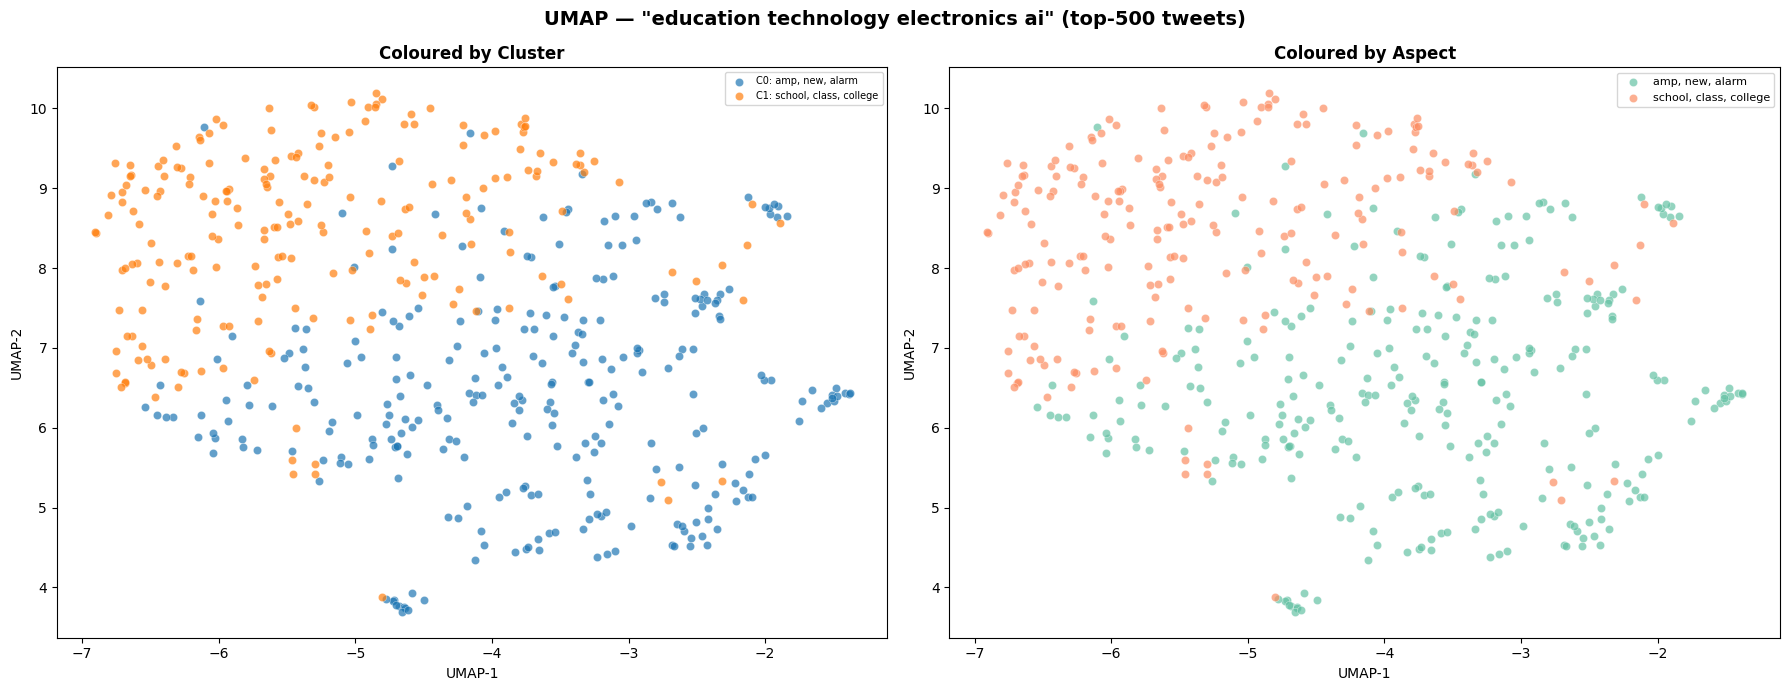

Dual UMAP comparison saved.


In [17]:
# ── UMAP coloured by aspect ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: cluster colouring
for cid in range(CHOSEN_K):
    mask = retrieved['cluster'] == cid
    label_terms = ', '.join([t[0] for t in top_terms[cid][:3]])
    axes[0].scatter(
        retrieved.loc[mask, 'umap_x'], retrieved.loc[mask, 'umap_y'],
        c=[palette[cid]], label=f'C{cid}: {label_terms}',
        alpha=0.7, s=35, edgecolors='white', linewidth=0.3,
    )
axes[0].set_title('Coloured by Cluster', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=7, loc='best')
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')

# Right: aspect colouring
aspect_names = sorted(retrieved['aspect'].unique())
aspect_palette = sns.color_palette('Set2', n_colors=len(aspect_names))
for i, asp in enumerate(aspect_names):
    mask = retrieved['aspect'] == asp
    axes[1].scatter(
        retrieved.loc[mask, 'umap_x'], retrieved.loc[mask, 'umap_y'],
        c=[aspect_palette[i]], label=asp,
        alpha=0.7, s=35, edgecolors='white', linewidth=0.3,
    )
axes[1].set_title('Coloured by Aspect', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8, loc='best')
axes[1].set_xlabel('UMAP-1')
axes[1].set_ylabel('UMAP-2')

fig.suptitle(f'UMAP — "{QUERY}" (top-{TOP_K} tweets)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(AGG_DIR / 'umap_cluster_vs_aspect.png', dpi=120)
plt.show()

print('Dual UMAP comparison saved.')

**Αποτέλεσμα:** Το dual UMAP plot επιβεβαιώνει ότι clusters και aspects ταυτίζονται πλήρως: αριστερά φαίνεται ο χρωματισμός ανά cluster και δεξιά ο χρωματισμός ανά aspect. Τα δύο νέφη σημείων είναι διαχωρισμένα στο 2D space. Το plot αποθηκεύτηκε στο `data/aggregation/umap_cluster_vs_aspect.png`.

![UMAP Comparison — Coloured by Cluster vs Aspect](../data/aggregation/umap_cluster_vs_aspect.png)


## 8. Αποθήκευση Aggregation Results

Αποθηκεύουμε το enriched DataFrame με retrieval scores, cluster labels, UMAP coordinates, aspect labels και aspect scores. Αυτά τα artefacts χρησιμοποιούνται από το επόμενο notebook για report generation.


In [18]:
# ── Save enriched retrieved dataframe ──────────────────────────────────────────
out_path = AGG_DIR / f'retrieved_aggregated.parquet'
retrieved.to_parquet(out_path, index=False)

print(f'Aggregated results saved to: {out_path}')
print(f'Shape  : {retrieved.shape}')
print(f'Columns: {list(retrieved.columns)}')

# ── List saved artefacts ───────────────────────────────────────────────────────
print(f'\nArtefacts in {AGG_DIR}:')
for p in sorted(AGG_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name:45s} {size_kb:>8.1f} KB')


Aggregated results saved to: /home/konstantinos-papadogiannis/Desktop2/SocialMediaAgent/data/aggregation/retrieved_aggregated.parquet
Shape  : (500, 25)
Columns: ['rank', 'ID', 'Tweet', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust', 'split', 'text_clean', 'text_light', 'n_tokens_clean', 'n_tokens_light', 'hybrid_score', 'cluster', 'umap_x', 'umap_y', 'aspect', 'aspect_score']

Artefacts in /home/konstantinos-papadogiannis/Desktop2/SocialMediaAgent/data/aggregation:
  elbow_silhouette.png                              75.5 KB
  emotion_per_aspect_bars.png                       53.1 KB
  emotion_per_aspect_heatmap.png                    61.4 KB
  emotion_per_cluster.png                           49.9 KB
  retrieved_aggregated.parquet                     126.6 KB
  umap_cluster_vs_aspect.png                       145.3 KB
  umap_clusters.png                                 71.0 KB


**Αποτέλεσμα:** Αποθηκεύτηκε το enriched DataFrame `retrieved_aggregated.parquet` στο `data/aggregation/` με τις αρχικές στήλες και επιπλέον `cluster`, `umap_x`, `umap_y`, `aspect`, `aspect_score` και `hybrid_score`. Επίσης υπάρχουν τα aggregation visualizations που δημιουργήθηκαν στα προηγούμενα βήματα. Το pipeline aggregation ολοκληρώνεται εδώ: query → retrieved tweets → clusters → aspects → summaries.
